In [7]:
!pip install catboost

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
import shap

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/drive/MyDrive/data_v2.csv')
df.head(5)

,yqc_cd,year,quarter,ds,gu_cd,gu_nm,dong_cd,dong_nm,dong_area,business_cd,...,SEL_close_avg,wp_total,rp_total,apt_cnt,apt_price,business_cat,wp_missing,rp_missing,apt_cnt_missing,apt_price_missing
0,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,48,6476,13047,342,243371110,음식(한식),0,0,1,1
1,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100002,...,48,6476,13047,342,243371110,음식(중식),0,0,1,1
2,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100003,...,48,6476,13047,342,243371110,음식(일식),0,0,1,1
3,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100004,...,48,6476,13047,342,243371110,음식(양식),0,0,1,1
4,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100005,...,48,6476,13047,342,243371110,음식(빵집),0,0,1,1


### EDA

Step 1. 시계열 패널 데이터 연속성 확인

전체 상권-업종 조합 수: 19018
총 24개 분기가 모두 존재하는 조합의 비율: 74.66%


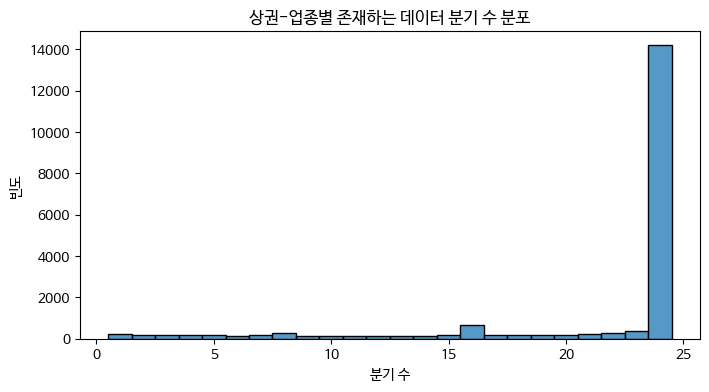

In [5]:
# 행정동(dong_cd)과 업종(business_cd) 조합별로 데이터가 존재하는 분기(yqc_cd) 수 확인
continuity_check = df.groupby(['dong_cd', 'business_cd'])['yqc_cd'].nunique()

print("전체 상권-업종 조합 수:", len(continuity_check))
print("총 24개 분기가 모두 존재하는 조합의 비율: {:.2f}%".format((continuity_check == 24).mean() * 100))

# 24개 분기가 안 되는(중간에 생기거나 폐업한) 조합이 얼마나 되는지 분포 확인
plt.figure(figsize=(8, 4))
sns.histplot(continuity_check, bins=24, discrete=True)
plt.title("상권-업종별 존재하는 데이터 분기 수 분포")
plt.xlabel("분기 수")
plt.ylabel("빈도")
plt.show()

Step 2. 전체 기간 매출 트렌드 (코로나 및 계절성 파악)

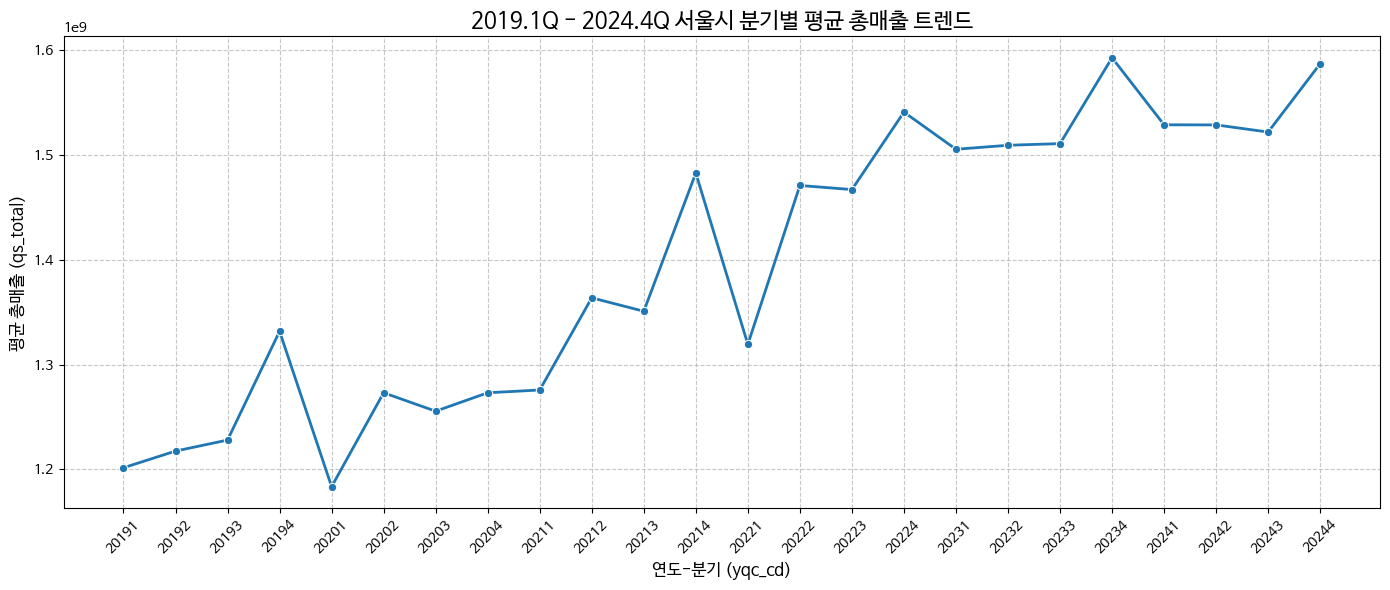

In [4]:
# 분기별 평균 총매출 집계
trend_df = df.groupby('yqc_cd')['qs_total'].mean().reset_index()

plt.figure(figsize=(14, 6))
# yqc_cd를 문자열로 변환하여 x축이 깔끔하게 나오도록 함
sns.lineplot(data=trend_df, x=trend_df['yqc_cd'].astype(str), y='qs_total', marker='o', linewidth=2)

plt.title("2019.1Q - 2024.4Q 서울시 분기별 평균 총매출 트렌드", fontsize=16)
plt.xlabel("연도-분기 (yqc_cd)", fontsize=12)
plt.ylabel("평균 총매출 (qs_total)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Step 3. '성장/유지/위축' 라벨링을 위한 증감률 기준선 찾기

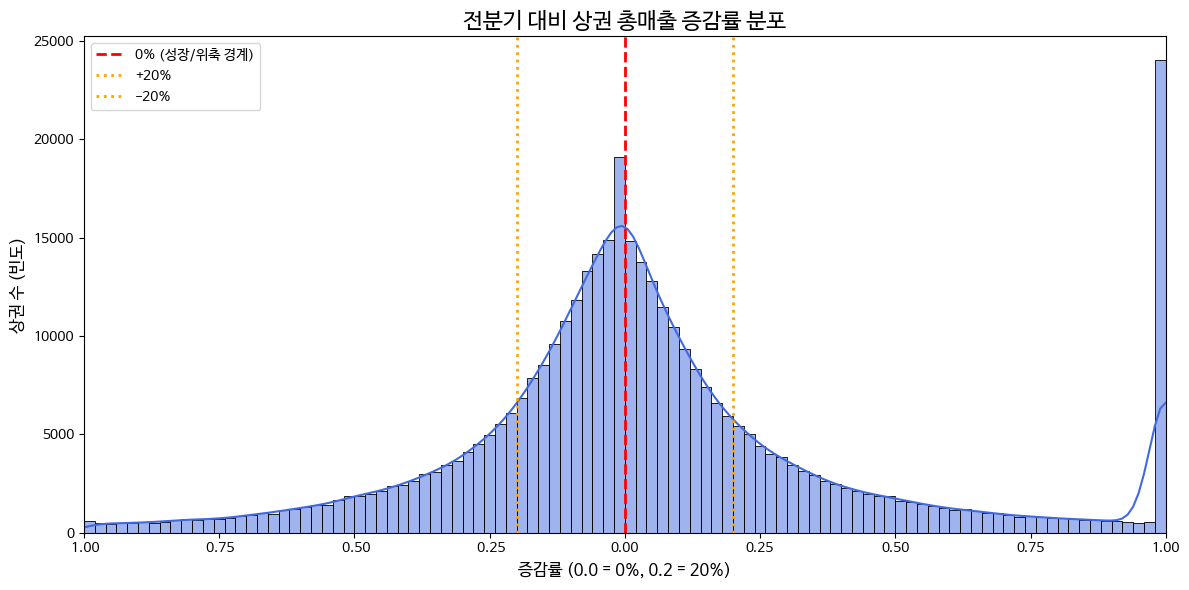

=== 매출 증감률 주요 통계량 ===
count    385205.000000
mean          3.026195
std         665.584359
min          -0.999998
10%          -0.359209
25%          -0.141287
50%           0.002650
75%           0.191246
90%           0.608683
max      371900.740525
Name: growth_rate, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

# 경고문 무시
warnings.filterwarnings('ignore')

# OS별 한글 폰트 설정 (로컬 주피터 노트북 기준)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic') # 맥
else:
    plt.rc('font', family='NanumBarunGothic') # 코랩/리눅스

# 1. 데이터 정렬 및 복사 (SettingWithCopyWarning 방지)
df = df.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).copy()

# 2. 전분기 대비 매출 증감률(growth_rate) 계산
df['growth_rate'] = df.groupby(['dong_cd', 'business_cd'])['qs_total'].pct_change()

# 3. 분석을 위한 데이터 정제 (무한대 값과 결측치 제거)
df['growth_rate'] = df['growth_rate'].replace([np.inf, -np.inf], np.nan)
growth_data = df.dropna(subset=['growth_rate'])['growth_rate']

# 4. 히스토그램 시각화 (극단적인 이상치를 제외하고 -100% ~ +100% 구간만 확대)
plt.figure(figsize=(12, 6))
# 데이터가 너무 많을 경우를 대비해 구간(bins)을 세밀하게 나눔
sns.histplot(growth_data.clip(-1, 1), bins=100, kde=True, color='royalblue')

# 기준선 표시 (0%)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='0% (성장/위축 경계)')
plt.axvline(x=0.2, color='orange', linestyle=':', linewidth=2, label='+20%')
plt.axvline(x=-0.2, color='orange', linestyle=':', linewidth=2, label='-20%')

plt.title("전분기 대비 상권 총매출 증감률 분포", fontsize=16)
plt.xlabel("증감률 (0.0 = 0%, 0.2 = 20%)", fontsize=12)
plt.ylabel("상권 수 (빈도)", fontsize=12)
plt.xlim(-1, 1)
plt.legend()
plt.tight_layout()
plt.show()

# 5. 주요 통계량 확인
print("=== 매출 증감률 주요 통계량 ===")
print(growth_data.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

### Feature Engineering

In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df_feat = df.copy()

# ==========================================
# [1] 기본 스케일 변수 (로그 변환)
# ==========================================
log_cols = ['qs_total', 'fp_total', 'wp_total', 'rp_total', 'apt_price', 'subway_station', 'bus_station']
for col in log_cols:
    df_feat[f'{col}_log'] = np.log1p(df_feat[col])

# ==========================================
# [2] 상권 경쟁력 및 효율 지표
# ==========================================
safe_store_cnt = df_feat['similar_store_cnt'].replace(0, 1)
df_feat['sales_per_store'] = df_feat['qs_total'] / safe_store_cnt
df_feat['store_density'] = df_feat['similar_store_cnt'] / df_feat['dong_area']
df_feat['ATV'] = (df_feat['qs_total'] / df_feat['qsc_total'].replace(0, 1)).fillna(0)

# ==========================================
# [3] 시간대/요일/연령대 비율 (폭넓게 모두 추가!)
# ==========================================
safe_qs_total = df_feat['qs_total'].replace(0, 1)

# 요일 비중
df_feat['sales_weekdays_ratio'] = df_feat['qs_weekdays'] / safe_qs_total
df_feat['sales_weekend_ratio'] = df_feat['qs_weekend'] / safe_qs_total

# 시간대 비중
df_feat['sales_lunch_ratio'] = df_feat['qs_1114'] / safe_qs_total   # 점심
df_feat['sales_afternoon_ratio'] = df_feat['qs_1417'] / safe_qs_total # 오후
df_feat['sales_evening_ratio'] = df_feat['qs_1721'] / safe_qs_total # 저녁 (퇴근/회식)
df_feat['sales_night_ratio'] = df_feat['qs_2124'] / safe_qs_total   # 심야 (유흥)

# 연령대 비중
df_feat['sales_2030_ratio'] = (df_feat['qs_20'] + df_feat['qs_30']) / safe_qs_total # 트렌드 주도층
df_feat['sales_3050_ratio'] = (df_feat['qs_30'] + df_feat['qs_40'] + df_feat['qs_50']) / safe_qs_total # 머니 파워 (직장인/가족)
df_feat['sales_60_ratio'] = df_feat['qs_60'] / safe_qs_total # 시니어

# ==========================================
# [4] 인프라 지표
# ==========================================
df_feat['is_univ'] = (df_feat['university'] > 0).astype(int)
df_feat['edu_cnt'] = df_feat['kindergarden'] + df_feat['ele_school'] + df_feat['mid_school'] + df_feat['high_school']
df_feat['traffic_score'] = (df_feat['subway_station_log'] * 3) + df_feat['bus_station_log']

In [10]:
# ==========================================
# [5] 상권 특성 클러스터링 (K-Means)
# ==========================================
# 클러스터링에 사용할 비율 데이터들만 추출
cluster_features = [
    'sales_weekdays_ratio', 'sales_weekend_ratio',
    'sales_lunch_ratio', 'sales_evening_ratio', 'sales_night_ratio',
    'sales_2030_ratio', 'sales_3050_ratio'
]

# K-Means는 거리를 기반으로 하므로 스케일링 필수
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_feat[cluster_features].fillna(0))

# 군집 개수는 임의로 4개로 설정 (예: 직장인상권, 대학가/유흥상권, 주거지상권, 기타)
kmeans = KMeans(n_clusters=4, random_state=42)
df_feat['cluster_id'] = kmeans.fit_predict(scaled_data)

# 결과 확인 (직접 눈으로 뜯어보기)
print("=== 클러스터별 상권-분기 데이터 개수 ===")
print(df_feat['cluster_id'].value_counts().sort_index())

print("\n=== 클러스터별 주요 피처 평균값 ===")
cluster_means = df_feat.groupby('cluster_id')[cluster_features].mean()

display(cluster_means.round(3))

=== 클러스터별 상권-분기 데이터 개수 ===
cluster_id
0     63114
1    150084
2     65795
3    125230
Name: count, dtype: int64

=== 클러스터별 주요 피처 평균값 ===


,sales_weekdays_ratio,sales_weekend_ratio,sales_lunch_ratio,sales_evening_ratio,sales_night_ratio,sales_2030_ratio,sales_3050_ratio
cluster_id,,,,,,,
0,0.918,0.082,0.129,0.442,0.047,0.259,0.807
1,0.659,0.341,0.250,0.347,0.050,0.314,0.634
2,0.687,0.313,0.070,0.327,0.320,0.412,0.614
3,0.870,0.130,0.340,0.177,0.012,0.181,0.516


In [11]:
# ==========================================
# [6] 모델에 넣을 최종 피처 리스트 총망라
# ==========================================
final_features = [
    'yqc_cd', 'dong_cd', 'business_cd',
    'qs_total_log', 'fp_total_log', 'wp_total_log', 'rp_total_log', 'apt_price_log',
    'sales_per_store', 'store_density', 'ATV',
    'sales_weekdays_ratio', 'sales_weekend_ratio',
    'sales_lunch_ratio', 'sales_afternoon_ratio', 'sales_evening_ratio', 'sales_night_ratio',
    'sales_2030_ratio', 'sales_3050_ratio', 'sales_60_ratio',
    'is_univ', 'edu_cnt', 'traffic_score',
    'cluster_id' # 새롭게 생성된 클러스터 ID
]

df_final = df_feat[final_features].copy()

print("=== 피처 엔지니어링 & 클러스터링 완료 ===")
print("총 피처 개수:", len(final_features) - 3) # 식별자 3개 제외
print("\n[상권 클러스터 분포]")
print(df_final['cluster_id'].value_counts())

=== 피처 엔지니어링 & 클러스터링 완료 ===
총 피처 개수: 21

[상권 클러스터 분포]
cluster_id
1    150084
3    125230
2     65795
0     63114
Name: count, dtype: int64


####Sliding Window (과거 데이터 시프트)

$t$ 분기의 타겟(성장/유지/위축)을 예측하기 위해, 모델의 입력(Input) 피처들은 전부 $t-1$ 분기(또는 그 이전)의 데이터를 바라보도록 짝을 맞춰주는 작업

In [12]:
import pandas as pd
import numpy as np

# 1. 데이터 정렬 (누수 방지의 핵심: 상권별, 업종별, 시간순으로 반드시 정렬해야 합니다!)
df_feat = df_feat.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)
df_final = df_final.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

# 2. 타겟(Target) 생성 (원본 데이터인 df_feat에서 qs_total을 이용해 계산)
# 전분기 대비 매출 증감률 계산
df_feat['growth_rate'] = df_feat.groupby(['dong_cd', 'business_cd'])['qs_total'].pct_change()
df_feat['growth_rate'] = df_feat['growth_rate'].replace([np.inf, -np.inf], np.nan)

# ±20% 기준으로 위축(0), 유지(1), 성장(2) 라벨링
df_final['target'] = pd.cut(
    df_feat['growth_rate'],
    bins=[-np.inf, -0.2, 0.2, np.inf],
    labels=[0, 1, 2]
)

# 3. Shift(한 칸 밀기)를 적용할 피처 리스트 뽑기
# 식별자(상권, 업종, 시간)는 밀면 안 되니까 제외합니다.
shift_cols = [col for col in df_final.columns if col not in ['yqc_cd', 'dong_cd', 'business_cd', 'target']]

# 4. Sliding Window (Shift) 적용
df_shifted = df_final.copy()
for col in shift_cols:
    # 상권-업종별로 묶은 뒤, 1분기 전의 데이터를 'prev_'라는 이름표를 붙여서 가져옵니다.
    df_shifted[f'prev_{col}'] = df_shifted.groupby(['dong_cd', 'business_cd'])[col].shift(1)

# 5. 최종 머신러닝용 데이터셋 조립 (식별자 + 타겟 + 과거 피처)
model_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target'] + [f'prev_{col}' for col in shift_cols]
df_model = df_shifted[model_cols].copy()

# 6. 결측치 제거
# shift(1)을 했기 때문에 2019년 1분기(이전 데이터가 없는 분기) 등은 자연스럽게 NaN이 되어 떨어져 나갑니다.
df_model = df_model.dropna().reset_index(drop=True)

print("=== 최종 머신러닝용 데이터셋 (df_model) 완성 ===")
print("데이터 쉐이프:", df_model.shape)
print("\n[Target 클래스 비율 확인]")
print(df_model['target'].value_counts(normalize=True).sort_index() * 100)

=== 최종 머신러닝용 데이터셋 (df_model) 완성 ===
데이터 쉐이프: (385205, 25)

[Target 클래스 비율 확인]
target
0    19.116055
1    56.526265
2    24.357680
Name: proportion, dtype: float64


In [13]:
df_model.head(5)

,dong_cd,business_cd,yqc_cd,target,prev_qs_total_log,prev_fp_total_log,prev_wp_total_log,prev_rp_total_log,prev_apt_price_log,prev_sales_per_store,...,prev_sales_afternoon_ratio,prev_sales_evening_ratio,prev_sales_night_ratio,prev_sales_2030_ratio,prev_sales_3050_ratio,prev_sales_60_ratio,prev_is_univ,prev_edu_cnt,prev_traffic_score,prev_cluster_id
0,11110515,CS100001,20192,1,21.386510,15.115219,8.776013,9.476390,19.310098,2.426349e+07,...,0.108466,0.339677,0.161194,0.318089,0.528391,0.081971,1.0,6.0,3.295837,1.0
1,11110515,CS100001,20193,1,21.470838,15.156251,8.776013,9.475086,19.310098,2.673250e+07,...,0.101477,0.342767,0.150563,0.319993,0.525832,0.107766,1.0,6.0,3.295837,1.0
2,11110515,CS100001,20194,2,21.438412,15.151398,8.776013,9.475086,19.310098,2.690112e+07,...,0.097503,0.346854,0.147596,0.323724,0.515234,0.116989,1.0,6.0,3.295837,1.0
3,11110515,CS100001,20201,0,21.692543,15.196653,8.776013,9.458606,19.310098,3.336758e+07,...,0.096200,0.370518,0.147147,0.317732,0.480645,0.112008,1.0,6.0,3.295837,1.0
4,11110515,CS100001,20202,1,21.446476,15.099848,8.776013,9.458606,19.310098,2.748052e+07,...,0.094957,0.357403,0.142621,0.341881,0.529797,0.109664,1.0,6.0,3.295837,1.0


### 모델 학습

1. OOT 분할 및 다중 모델 베이스라인 평가


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import warnings
warnings.filterwarnings('ignore')

# 1. 모델 피처(X)와 타겟(y) 분리 (식별자 제거)
# 이전 단계에서 만든 df_model을 시간순으로 다시 한번 꽉 잡아줍니다.
df_model = df_model.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

drop_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target']
X = df_model.drop(columns=drop_cols)
y = df_model['target'].astype(int)

print(f"=== 데이터 준비 완료 (Shape: {X.shape}) ===")

# 2. GPU 지원 모델 3대장 세팅 (클래스 불균형 고려)
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softmax', num_class=3,
        tree_method='hist', device='cuda', # GPU 세팅
        random_state=42
    ),
    'LightGBM': lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        device='gpu', # GPU 세팅 (코랩 환경에 따라 CPU로 돌아갈 수도 있음)
        class_weight='balanced', random_state=42,
        verbose=-1  # 지저분한 경고문 끄기
    ),
    'CatBoost': cb.CatBoostClassifier(
        loss_function='MultiClass',
        task_type='GPU', # GPU 세팅
        auto_class_weights='Balanced', random_state=42, verbose=0
    )
}

# 3. 시계열 교차 검증 (TimeSeriesSplit)
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

# 결과를 저장할 딕셔너리
cv_results = {model_name: [] for model_name in models.keys()}

print("\n=== GPU 다중 모델 TimeSeriesSplit 평가 시작 ===")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"\n[Fold {fold + 1}/{n_splits}]")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    for name, model in models.items():
        # 모델 학습
        model.fit(X_train, y_train)

        # 검증셋 예측 및 성능 평가 (Macro F1)
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average='macro')
        cv_results[name].append(score)

        print(f" - {name} F1 Score: {score:.4f}")

# 4. 최종 베이스라인 결과 요약
print("\n=== 3대장 모델 베이스라인 평균 성능 ===")
for name, scores in cv_results.items():
    mean_score = np.mean(scores)
    print(f"[{name}] 평균 Macro F1: {mean_score:.4f} (Fold별: {[round(s, 4) for s in scores]})")

=== 데이터 준비 완료 (Shape: (385205, 21)) ===

=== 🚀 GPU 다중 모델 TimeSeriesSplit 평가 시작 ===

[Fold 1/3]
 - XGBoost F1 Score: 0.4777
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4405
[LightGBM] [Info] Number of data points in the train set: 96302, number of used features: 21
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-80GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 20 dense feature groups (1.84 MB) transferred to GPU in 0.003474 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
 - LightGBM F1 Score: 0.5074
 - CatBoost F1 Score: 0.4997

[Fold 2/3]
 - XGBoost F1 Score: 0.4772
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4475
[LightGBM] [In

2. TimeSeriesSplit + GridSearch 하이퍼파라미터 튜닝

In [17]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

tscv = TimeSeriesSplit(n_splits=3)

# GPU 모델 셋팅
lgb_base = lgb.LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    device='gpu',
    random_state=42,
    n_estimators=200, # 속도를 위해 적당한 트리 개수 지정
    verbose=-1
)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'num_leaves': [31, 63, 127],
    'min_child_samples': [20, 50]
}

print(f"=== LightGBM GridSearch 튜닝 시작 (총 54개 조합 x 3 Folds) ===")

gsearch_lgb = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=tscv,
    verbose=2,
    n_jobs=1    # 핵심 수정: GPU 충돌 방지를 위해 반드시 1로 설정!
)

# 튜닝 실행
gsearch_lgb.fit(X, y)

print("\n=== 튜닝 완료! 최적의 파라미터 ===")
print("Best Parameters:", gsearch_lgb.best_params_)
print(f"Best Macro F1 Score: {gsearch_lgb.best_score_:.4f}")

best_lgb_model = gsearch_lgb.best_estimator_

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

변수 중요도(Feature Importance) 확인

=== 🚀 최종 튜닝 모델 학습 시작 ===
=== 학습 완료! ===


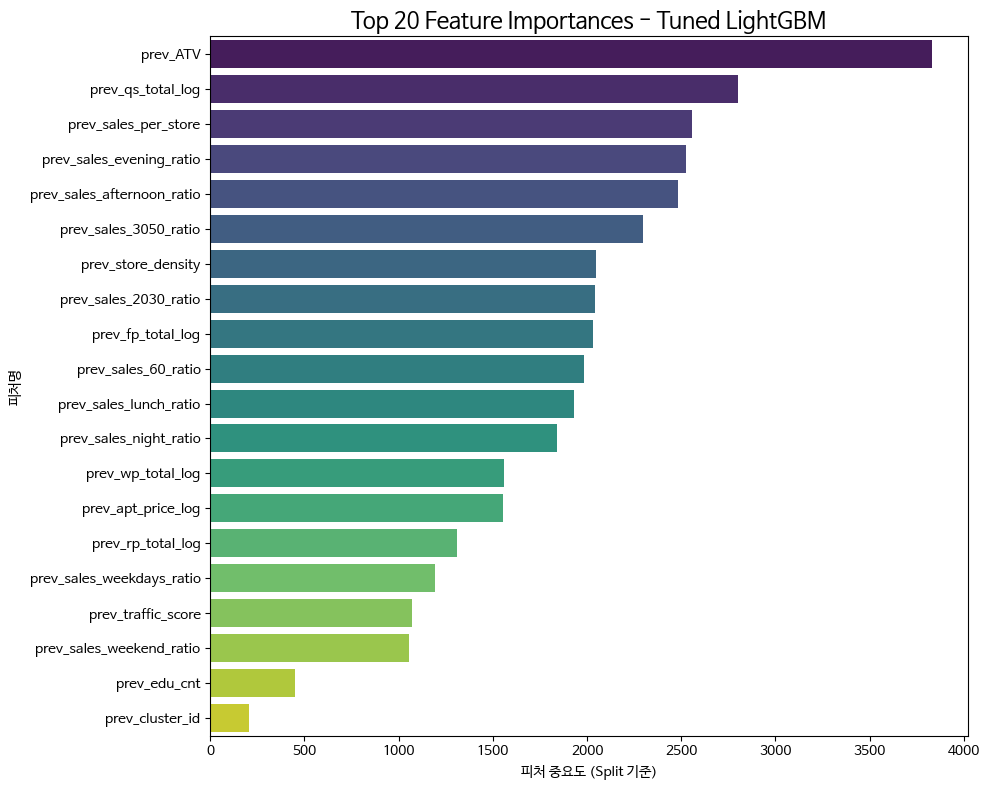

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 튜닝된 최적의 파라미터 + 경고문 끄기(verbose=-1) 적용
best_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    device='gpu',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_child_samples=50,
    num_leaves=63,
    verbose=-1
)

# 2. 전체 데이터(X, y)로 최종 모델 학습
print("=== 최종 튜닝 모델 학습 시작 ===")
best_lgb.fit(X, y)
print("=== 학습 완료! ===")

# 3. 변수 중요도(Feature Importance) 추출 및 시각화
ftr_importances_values = best_lgb.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X.columns)

# 상위 20개 피처만 추출
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(10, 8))
plt.title('Top 20 Feature Importances - Tuned LightGBM', fontsize=16)
sns.barplot(x=ftr_top20, y=ftr_top20.index, palette='viridis')
plt.xlabel("피처 중요도 (Split 기준)")
plt.ylabel("피처명")
plt.tight_layout()
plt.show()

3. CatBoost 튜닝 및 LightGBM + CatBoost 앙상블

In [19]:
import catboost as cb
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

# ==========================================
# 1. CatBoost 모델 세팅 및 GridSearch 튜닝
# ==========================================
cat_base = cb.CatBoostClassifier(
    loss_function='MultiClass',
    task_type='GPU',
    auto_class_weights='Balanced',
    verbose=0,
    random_state=42
)

# CatBoost는 기본 성능이 좋아 핵심 파라미터만 탐색합니다.
param_grid_cat = {
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'iterations': [200, 500]
}

print("=== CatBoost GridSearch 튜닝 시작 (총 18개 조합 x 3 Folds) ===")
gsearch_cat = GridSearchCV(
    estimator=cat_base,
    param_grid=param_grid_cat,
    scoring='f1_macro',
    cv=tscv,
    verbose=2,
    n_jobs=1  # GPU 데드락 방지
)

# 튜닝 실행 (X, y 사용)
gsearch_cat.fit(X, y)

print("\n=== CatBoost 튜닝 완료 ===")
print("Best Parameters:", gsearch_cat.best_params_)
print(f"Best Macro F1 Score: {gsearch_cat.best_score_:.4f}")

best_cat_model = gsearch_cat.best_estimator_

=== 🔍 CatBoost GridSearch 튜닝 시작 (총 18개 조합 x 3 Folds) ===
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END ........depth=4, iterations=200, learning_rate=0.01; total time=   1.0s
[CV] END ........depth=4, iterations=200, learning_rate=0.01; total time=   3.0s
[CV] END ........depth=4, iterations=200, learning_rate=0.01; total time=   3.1s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   2.9s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   3.0s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   3.0s
[CV] END .........depth=4, iterations=200, learning_rate=0.1; total time=   2.9s
[CV] END .........depth=4, iterations=200, learning_rate=0.1; total time=   3.0s
[CV] END .........depth=4, iterations=200, learning_rate=0.1; total time=   3.0s
[CV] END ........depth=4, iterations=500, learning_rate=0.01; total time=   4.0s
[CV] END ........depth=4, iterations=500, learning_rate=0.01; total time

In [20]:
# ==========================================
# 2. 최종 앙상블 (LightGBM + CatBoost Soft Voting)
# ==========================================

best_lgb_model = gsearch_lgb.best_estimator_

print("\n=== 앙상블 (LightGBM + CatBoost) 최종 OOT 평가 ===")

# OOT 분할 기준점 (2024년 1분기 기준, 이전 코드와 동일)
split_point = 20241

# OOT Test 셋 준비 (미래 데이터)
test_df = df_model[df_model['yqc_cd'] >= split_point]
X_test = test_df.drop(columns=['dong_cd', 'business_cd', 'yqc_cd', 'target'])
y_test = test_df['target'].astype(int)

# OOT Train 셋 준비 및 최종 학습 (과거 데이터)
train_df = df_model[df_model['yqc_cd'] < split_point]
X_train = train_df.drop(columns=['dong_cd', 'business_cd', 'yqc_cd', 'target'])
y_train = train_df['target'].astype(int)

# 튜닝된 파라미터로 전체 Train 셋 재학습
print("최종 모델 학습 중...")
best_lgb_model.fit(X_train, y_train)
best_cat_model.fit(X_train, y_train)

# 각 모델이 예측한 클래스별 '확률(Probability)' 추출
proba_lgb = best_lgb_model.predict_proba(X_test)
proba_cat = best_cat_model.predict_proba(X_test)

# Soft Voting: 두 모델의 예측 확률을 5:5로 더함
proba_ensemble = (proba_lgb + proba_cat) / 2

# 가장 확률이 높은 클래스를 최종 예측값으로 선택
y_pred_ensemble = np.argmax(proba_ensemble, axis=1)

# 최종 성능 평가
ensemble_f1 = f1_score(y_test, y_pred_ensemble, average='macro')

print(f"\n Final Ensemble Macro F1 Score: {ensemble_f1:.4f}")
print("\n[최종 앙상블 분류 리포트]")
print(classification_report(y_test, y_pred_ensemble, target_names=["위축형(0)", "유지형(1)", "성장형(2)"]))


=== 🤝 앙상블 (LightGBM + CatBoost) 최종 OOT 평가 ===
최종 모델 학습 중...

🌟 Final Ensemble Macro F1 Score: 0.5184

[최종 앙상블 분류 리포트]
              precision    recall  f1-score   support

      위축형(0)       0.35      0.53      0.42     12713
      유지형(1)       0.83      0.66      0.74     40981
      성장형(2)       0.38      0.43      0.40     13567

    accuracy                           0.59     67261
   macro avg       0.52      0.54      0.52     67261
weighted avg       0.65      0.59      0.61     67261



### 모델 분석

Confusion Matrix

=== 📊 1. 최종 앙상블 모델 Confusion Matrix ===


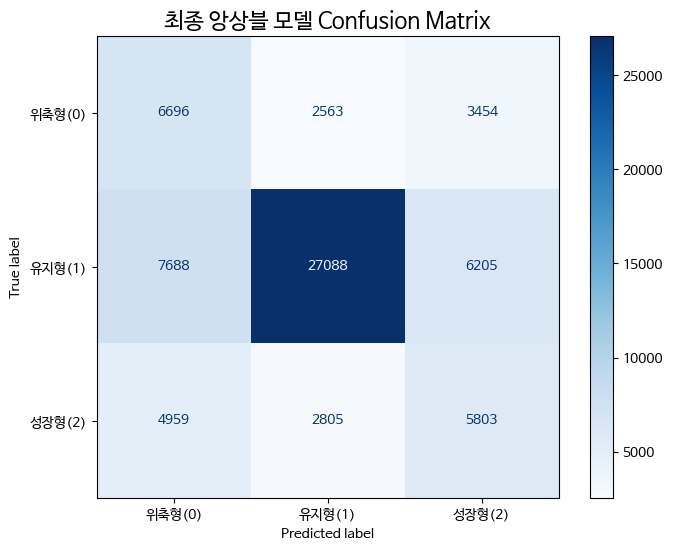

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# 한글 폰트 및 마이너스 기호 설정 (이전 설정 유지)
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# [1] 앙상블 모델 오답 노트 (Confusion Matrix)
# ==========================================
print("=== 📊 1. 최종 앙상블 모델 Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred_ensemble)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["위축형(0)", "유지형(1)", "성장형(2)"])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('최종 앙상블 모델 Confusion Matrix', fontsize=16)
plt.show()

Feature Importance


=== 🔍 2. LightGBM vs CatBoost 변수 중요도 비교 ===


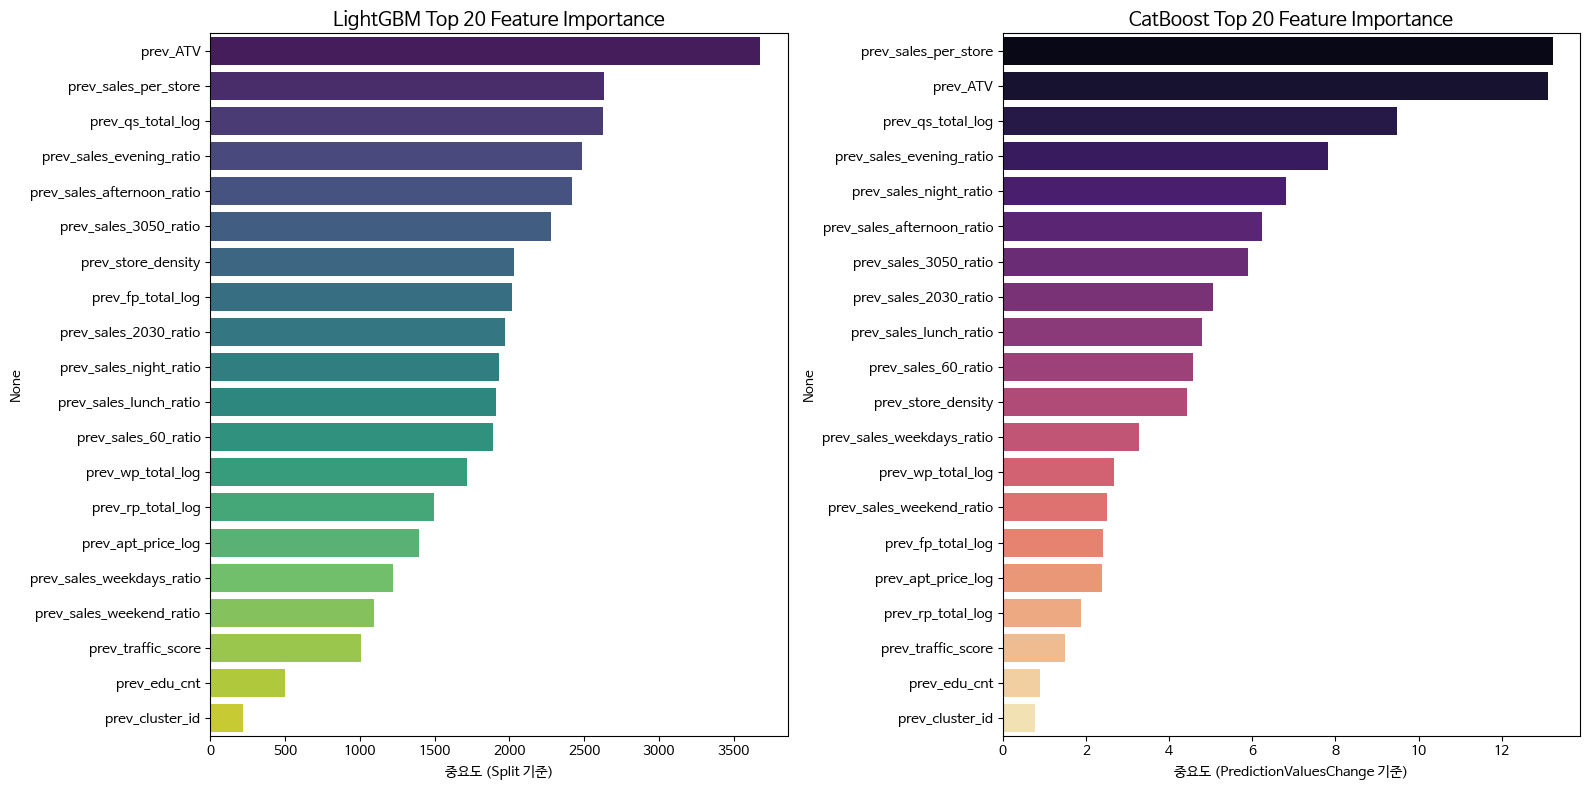

In [22]:
# ==========================================
# [2] 베이스 모델 Feature Importance 비교
# ==========================================
print("\n=== 2. LightGBM vs CatBoost 변수 중요도 비교 ===")

# LightGBM 변수 중요도 추출
lgb_importance = pd.Series(best_lgb_model.feature_importances_, index=X_train.columns)
lgb_top20 = lgb_importance.sort_values(ascending=False)[:20]

# CatBoost 변수 중요도 추출
cat_importance = pd.Series(best_cat_model.get_feature_importance(), index=X_train.columns)
cat_top20 = cat_importance.sort_values(ascending=False)[:20]

# 시각화 (두 모델 나란히 비교)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LightGBM 그래프
sns.barplot(x=lgb_top20, y=lgb_top20.index, ax=axes[0], palette='viridis')
axes[0].set_title('LightGBM Top 20 Feature Importance', fontsize=14)
axes[0].set_xlabel('중요도 (Split 기준)')

# CatBoost 그래프
sns.barplot(x=cat_top20, y=cat_top20.index, ax=axes[1], palette='magma')
axes[1].set_title('CatBoost Top 20 Feature Importance', fontsize=14)
axes[1].set_xlabel('중요도 (PredictionValuesChange 기준)')

plt.tight_layout()
plt.show()

SHAP 분석

=== 🔍 SHAP 분석: 무엇이 상권을 '성장'하게 만드는가? ===


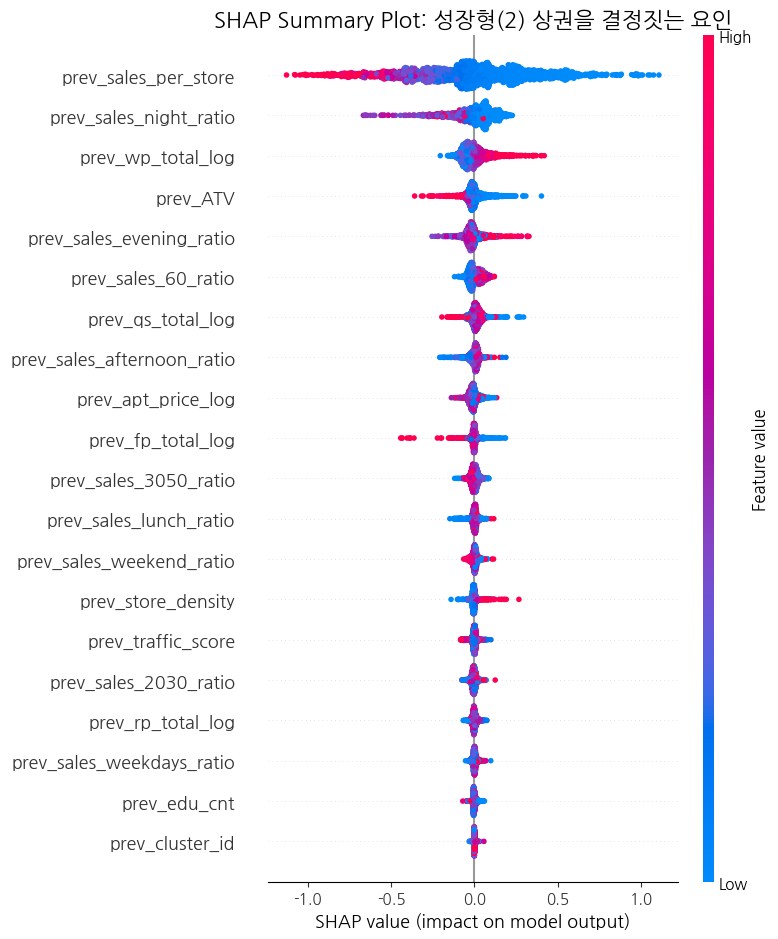

In [23]:
import shap
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 기호 설정 (코랩 환경)
plt.rcParams['font.family'] = 'NanumGothic' # 폰트가 깨진다면 이 부분은 환경에 맞게 조정해주세요.
plt.rcParams['axes.unicode_minus'] = False

print("=== SHAP 분석: 무엇이 상권을 '성장'하게 만드는가? ===")

# 1. SHAP TreeExplainer 초기화 (튜닝된 LightGBM 모델 사용)
explainer = shap.TreeExplainer(best_lgb_model)

# 2. 계산 속도를 위해 Test 셋에서 무작위로 2000개 샘플 추출
X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)

# 4. 다중 분류 3개 클래스(0:위축, 1:유지, 2:성장) 중 "2(성장형)"에 대한 SHAP 값 추출
# shap 버전이 최신일 경우 shap_values[:, :, 2] 형태로 인덱싱합니다. (구버전은 shap_values[2])
try:
    shap_values_target = shap_values[:, :, 2]
except IndexError:
    shap_values_target = shap_values[2]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot: 성장형(2) 상권을 결정짓는 요인", fontsize=16)

# 빨간 점(Feature 값이 높을 때)과 파란 점(Feature 값이 낮을 때)이
# 오른쪽(성장 확률 증가)과 왼쪽(성장 확률 감소) 중 어디로 향하는지 보여주는 그래프
shap.summary_plot(shap_values_target, X_test_sample, show=False)

plt.tight_layout()
plt.show()

=== 🚨 SHAP 분석: 무엇이 상권을 '위축(0)' 시키는가? ===


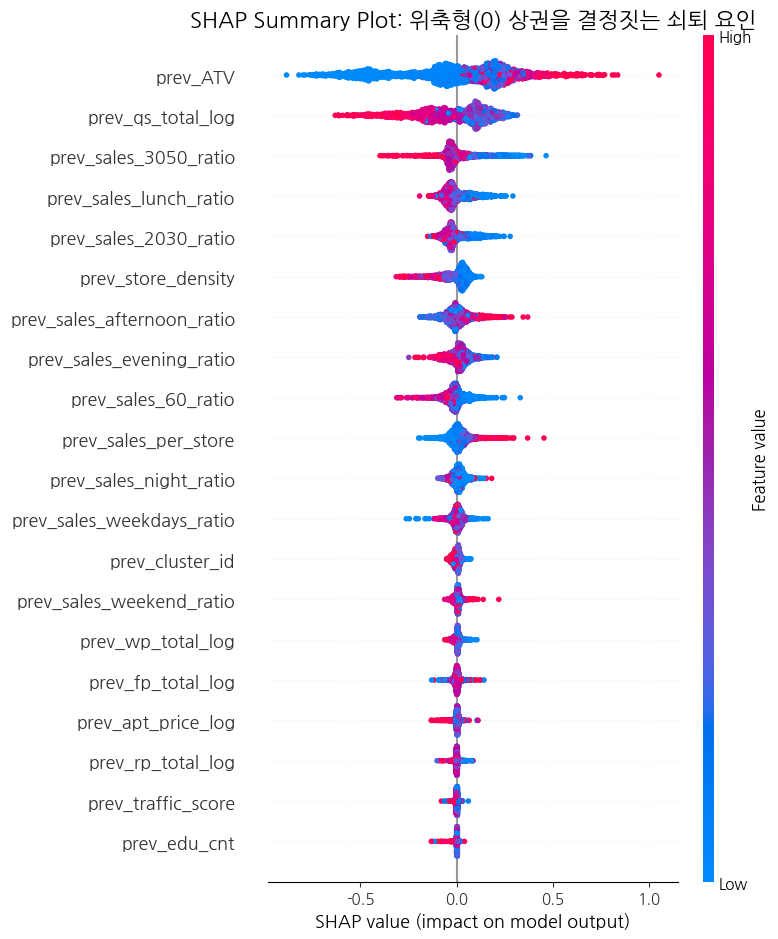

In [24]:
import shap
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'NanumGothic' # 필요시 환경에 맞게 수정
plt.rcParams['axes.unicode_minus'] = False

print("=== SHAP 분석: 무엇이 상권을 '위축(0)' 시키는가? ===")

# 1. SHAP TreeExplainer 초기화 (이미 되어있다면 생략 가능하지만 명확히 하기 위해 포함)
explainer = shap.TreeExplainer(best_lgb_model)

# 2. Test 셋에서 무작위로 샘플 추출 (아까 추출한 X_test_sample을 그대로 써도 됩니다)
# X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)

# 4. 다중 분류 3개 클래스 중 "0(위축형)"에 대한 SHAP 값 추출
try:
    shap_values_shrink = shap_values[:, :, 0]
except IndexError:
    shap_values_shrink = shap_values[0]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot: 위축형(0) 상권을 결정짓는 쇠퇴 요인", fontsize=16)

shap.summary_plot(shap_values_shrink, X_test_sample, show=False)

plt.tight_layout()
plt.show()

### 모델 저장


In [25]:
import joblib

model_path_lgb = "best_lgb_model.pkl"
model_path_cat = "best_cat_model.pkl"

joblib.dump(best_lgb_model, model_path_lgb)
joblib.dump(best_cat_model, model_path_cat)

print(f"모델 저장 완료: {model_path_lgb}, {model_path_cat}")

모델 저장 완료: best_lgb_model.pkl, best_cat_model.pkl


In [26]:
import json

# 평가 결과 저장
report_dict = classification_report(y_test, y_pred_ensemble,
                                    target_names=["위축형(0)", "유지형(1)", "성장형(2)"],
                                    output_dict=True)

evaluation_metrics = {
    "ensemble_f1_macro": ensemble_f1,
    "report": report_dict
}

with open("ensemble_evaluation.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_metrics, f, indent=4, ensure_ascii=False)

print("평가 결과 JSON 저장 완료!")

평가 결과 JSON 저장 완료!


In [27]:
from sklearn.ensemble import VotingClassifier
import joblib

# 1. 앙상블 모델 정의 (Soft Voting)
# 이미 학습된 best_lgb_model과 best_cat_model을 사용합니다.
ensemble_model = VotingClassifier(
    estimators=[
        ('lgb', best_lgb_model),
        ('cat', best_cat_model)
    ],
    voting='soft',
    weights=[1, 1] # 5:5 비중 (필요시 조정 가능)
)

# 2. 전체 데이터(X_train, y_train)로 최종 학습
# 배포용 모델은 가능한 많은 데이터를 학습해야 하므로 OOT 분할 없이 전체로 학습하기도 합니다.
ensemble_model.fit(X_train, y_train)

# 3. 배포용 단일 파일로 저장
model_filename = "final_ensemble_model.pkl"
joblib.dump(ensemble_model, model_filename)

print(f"배포용 모델 저장 완료: {model_filename}")

배포용 모델 저장 완료: final_ensemble_model.pkl
